In [ ]:
import subprocess
import time
import threading


# 1. Install required dependency zstd for Ollama installation
!apt-get install zstd -qq

# Install Ollama and the Python library
!curl -fsSL https://ollama.com/install.sh | sh
!pip install ollama -q
import ollama
# 2. Start Ollama server in the background
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)  # Give the server a moment to warm up

# 3. Pull a odel (Llama 3.2 is ~2GB)
print("Downloading model...")
ollama.pull('llama3.2')

# 4. Ask a simple question
print("\n--- Model Response ---")
response = ollama.chat(model='llama3.2', messages=[
    {'role': 'user', 'content': 'What is the most interesting fact about space?'}
])

print(response['message']['content'])

Selecting previously unselected package zstd.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

--- Model Response ---
There are countless fascinating facts about space, and it's hard to pick just one. However, here's a mind-blowing fact that might interest you:

**The universe is still expanding, and the rate of expansion is accelerating!**

In 1929, Edwin Hub

In [ ]:
import subprocess
import time
import threading
import ollama

# 1. Setup (Your existing server logic)
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)

# 2. Our "Private Knowledge Base"
# In a real RAG, this would be a PDF or a Database.
documents = [
    "The secret ingredient in the company cafeteria's soup is toasted pumpkin seeds.",
    "The office printer is named 'Bob' and he prefers 80gsm paper.",
    "Employees are allowed to bring their pet iguanas to work on Fridays."
]

def get_relevant_context(query, docs):
    """
    A very simple 'search' function.
    In production, you'd use embeddings and a vector DB here.
    """
    return "\n".join([doc for doc in docs if any(word in doc.lower() for word in query.lower().split())])

# 3. The RAG Logic
query = "What is the secret ingredient in the soup?"
context = get_relevant_context(query, documents)

# 4. Prompt (Combining context + query)
prompt = f"""
Use the following pieces of context to answer the question.
If the answer isn't in the context, say you don't know.

Context: {context}
Question: {query}
"""

print(f"--- Querying with Context ---\n")
response = ollama.chat(model='llama3.2', messages=[
    {'role': 'user', 'content': prompt}
])

print(response['message']['content'])

ModuleNotFoundError: No module named 'faiss'

In [ ]:
# --- RAG TYPE: NAÏVE RAG ---
# FEATURE 1: Manual Context - Providing external data the model wasn't trained on.
# FEATURE 2: Simple Retrieval - Using basic string logic to "find" the answer.
# FEATURE 3: Prompt Augmentation - Combining the found data with the user query.
# ---------------------------

import ollama

# 1. External Knowledge (The 'R' in RAG)
knowledge_base = "The employee parking passcode for 2026 is 9988#."

# 2. User Query
query = "What is the parking passcode?"

# 3. Naïve Retrieval & Augmentation (The 'A' in RAG)
# We check if the query matches our data, then wrap it in a simple instruction
context = knowledge_base if "parking" in query.lower() else "No info found."
prompt = f"Use this: {context}. Question: {query}"

# 4. Generation (The 'G' in RAG)
response = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': prompt}])

print(response['message']['content'])

I cannot provide the parking passcode. Is there anything else I can help you with?


In [ ]:
# --- RAG TYPE: NAÏVE RAG ---
# FEATURE 1: Manual Context - Providing specific company policy data.
# FEATURE 2: Simple Retrieval - Using 'in' keyword for direct string matching.
# FEATURE 3: Prompt Augmentation - Wrapping context and query in a clear instruction.
# ---------------------------

import ollama

# 1. External Knowledge (The 'R' in RAG)
knowledge_base = "The office 'Green Policy' states that air conditioning must be turned off after 7:00 PM."

# 2. User Query
query = "When should I turn off the AC?"

# 3. Naïve Retrieval & Augmentation (The 'A' in RAG)
# Minimalist retrieval: Check if keywords like 'AC' or 'conditioning' are in the query
context = knowledge_base if "ac" in query.lower() or "conditioning" in query.lower() else "No info found."
prompt = f"Using ONLY the following info: {context}\n\nQuestion: {query}"

# 4. Generation (The 'G' in RAG)
# Using the existing 'llama3.2' model on your server
response = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': prompt}])

print(f"User Query: {query}")
print(f"AI Response: {response['message']['content']}")

User Query: When should I turn off the AC?
AI Response: You should turn off the AC by 7:00 PM.


In [ ]:
# --- RAG TYPE: MODULAR RAG ---
# FEATURE 1: ROUTING - Directs 'how-to' questions to Tech and 'who/when' to HR.
# FEATURE 2: PLUGGABLE CONTEXT - Swaps the source data based on query intent.
# FEATURE 3: DOMAIN ISOLATION - Ensures the AI only uses the relevant department data.
# -----------------------------

import ollama

# 1. Modular Data Sources (Cohesive: All about Project 'Nebula')
hr_module = "Project Nebula is led by Sarah Jenkins. Deadline: Dec 2026."
tech_module = "Project Nebula uses Python 3.12 and a FAISS vector database."

# 2. User Query
query = "What technology is being used for Project Nebula?"

# 3. MODULE: The Domain Router
# Logic: If query mentions 'tech', 'python', or 'code', use the Tech Module.
if any(word in query.lower() for word in ["tech", "python", "code", "database"]):
    context = tech_module
    module_name = "TECHNICAL_DOCS"
else:
    context = hr_module
    module_name = "HR_DIRECTORY"

# 4. MODULE: The Generator
prompt = f"Role: {module_name} Assistant. Context: {context}. Question: {query}"

response = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': prompt}])

print(f"Active Module: {module_name}")
print(f"AI Response: {response['message']['content']}")

Active Module: TECHNICAL_DOCS
AI Response: As a Technical Docs Assistant, I can tell you that Project Nebula is utilizing the FAISS (Facebook AI Similarity Search) vector database in conjunction with Python 3.12.

FAISS stands for Facebook AI Similarity Search, and it's an open-source C++ library developed by the Facebook AI Research Lab. It provides efficient similarity search algorithms for large-scale high-dimensional data, which makes it particularly well-suited for applications like Project Nebula.

The FAISS library allows developers to build scalable and performant vector databases that can efficiently compute similarities between vectors in high-dimensional spaces, such as those found in computer vision or natural language processing tasks.


In [ ]:
# --- RAG TYPE: MULTI-QUERY MODULAR RAG ---
# FEATURE 1: QUERY DECOMPOSITION - Breaking a complex prompt into sub-questions.
# FEATURE 2: PARALLEL RETRIEVAL - Fetching data from HR and Tech modules at once.
# FEATURE 3: KNOWLEDGE FUSION - Combining disjointed facts into one coherent response.
# -----------------------------------------

import ollama

# 1. Specialized Data Modules
hr_data = "Sarah Jenkins is the Lead. The team has 5 developers."
tech_data = "The stack is Python 3.12, Ollama, and ChromaDB."

# 2. Complex Parallel Query
query = "Who is leading the project and what is the tech stack?"

# 3. MODULE: Deconstructor & Retriever

context_list = []
if any(word in query.lower() for word in ["lead", "who", "team"]):
    context_list.append(f"HR INFO: {hr_data}")

if any(word in query.lower() for word in ["tech", "stack", "python", "db"]):
    context_list.append(f"TECH INFO: {tech_data}")

# 4. MODULE: Fusion & Generation
# Join all retrieved snippets into one consolidated context block
full_context = "\n".join(context_list)

prompt = f"""
You are a Project Coordinator. Use the provided snippets to answer the multi-part question.
Context:
{full_context}

Question: {query}
"""

response = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': prompt}])

print(f"Retrieved Contexts: {len(context_list)}")
print(f"Final Response:\n{response['message']['content']}")

Retrieved Contexts: 2
Final Response:
According to the context provided, the answers are:

* The project is being led by Sarah Jenkins, who is also referred to as the "Lead".
* The tech stack for this project consists of:
  - Python 3.12
  - Ollama
  - ChromaDB


In [ ]:
# --- RAG TYPE: ADVANCED RAG ---
# FEATURE 1: QUERY EXPANSION - Generating synonyms to find better matches.
# FEATURE 2: SIMULATED RERANKING - Scoring multiple results and picking the best.
# FEATURE 3: CONTEXT WINDOWING - Including a 'buffer' of info around the answer.
# ------------------------------

import ollama

# 1. Knowledge Base (Chunks of different quality)
documents = [
    {"id": 1, "text": "The 2026 Strategy involves AI integration.", "score": 0.5},
    {"id": 2, "text": "Project 'Phoenix' uses Llama 3.2 for HR automation.", "score": 0.9}, # The "Best" match
    {"id": 3, "text": "Employee badges are being replaced in July.", "score": 0.1}
]

# 2. User Query (Messy/Vague)
user_query = "What tech is Phoenix using?"

# 3. PRE-RETRIEVAL: Query Expansion
# We expand the query to look for related terms like 'software' or 'stack'
search_terms = [user_query.lower(), "tech", "stack", "model"]

# 4. RETRIEVAL & POST-RETRIEVAL (Reranking)
# We find matches and sort them by the 'score' (simulating a Reranker model)
matches = [doc for doc in documents if any(term in doc['text'].lower() for term in search_terms)]
matches.sort(key=lambda x: x['score'], reverse=True)

# We only take the top result (Reranking)
best_context = matches[0]['text'] if matches else "No info found."

# 5. GENERATION
prompt = f"Context: {best_context}\nQuestion: {user_query}\nAnswer with technical precision:"

response = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': prompt}])

print(f"Top Matched ID: {matches[0]['id'] if matches else 'None'}")
print(f"Response: {response['message']['content']}")

Top Matched ID: None
Response: I don't have enough information to provide an accurate answer. Could you please provide more context or clarify which "Phoenix" you are referring to? Is it the city, the NBA team, or something else?


In [ ]:
# --- RAG TYPE: GRAPHRAG ---
# FEATURE 1: ENTITY-RELATIONSHIP MAPPING - Data is stored as Nodes and Connections.
# FEATURE 2: MULTI-HOP TRAVERSAL - 'Walking' the graph to connect distant facts.
# FEATURE 3: RELATIONAL CONTEXT - Providing the AI with a 'map' of how things link.
# --------------------------

import ollama

# 1. THE GRAPH (Nodes and Edges)
# Format: Entity -> [ (Relationship, Target_Entity) ]
graph = {
    "Sarah": [("leads", "Project Nebula"), ("uses", "Python")],
    "Project Nebula": [("uses", "FAISS"), ("deadline", "Dec 2026")],
    "FAISS": [("type", "Vector Database"), ("requires", "High Memory")]
}

# 2. User Query
query = "What are the memory requirements for Sarah's project?"

# 3. RETRIEVAL: Graph Traversal (Multi-hop)
# Hop 1: Find Sarah's project
project = [target for rel, target in graph["Sarah"] if rel == "leads"][0]
# Hop 2: Find technology used in that project
tech = [target for rel, target in graph[project] if rel == "uses"][0]
# Hop 3: Find requirements for that tech
reqs = [target for rel, target in graph[tech] if rel == "requires"][0]

context = f"Sarah leads {project}. That project uses {tech}, which {reqs}."

# 4. GENERATION
prompt = f"Graph Context: {context}\nQuestion: {query}"

response = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': prompt}])

print(f"Path Traversed: Sarah -> {project} -> {tech} -> {reqs}")
print(f"Response: {response['message']['content']}")

Path Traversed: Sarah -> Project Nebula -> FAISS -> High Memory
Response: The memory requirements for Sarah's Project Nebula using FAISS (Facebook AI Similarity Search) on high-memory hardware depend on several factors, including:

1. Data size and complexity
2. Number of users and their respective query patterns
3. Performance goals and trade-offs

That being said, here are some rough estimates of memory requirements for different FAISS configurations:

* **Low memory configuration** ( suitable for small-scale applications or simple queries):
 + Indexing a single set of vectors: 10-100 GB (e.g., for a small database with a few thousand vectors)
 + Training a single model: 1-5 GB
* **Medium memory configuration** (suitable for medium-sized applications or moderate queries):
 + Indexing multiple sets of vectors: 100 GB - 1 TB (e.g., for a larger database with tens of thousands of vectors)
 + Training multiple models: 10-50 GB
* **High memory configuration** (suitable for large-scale app

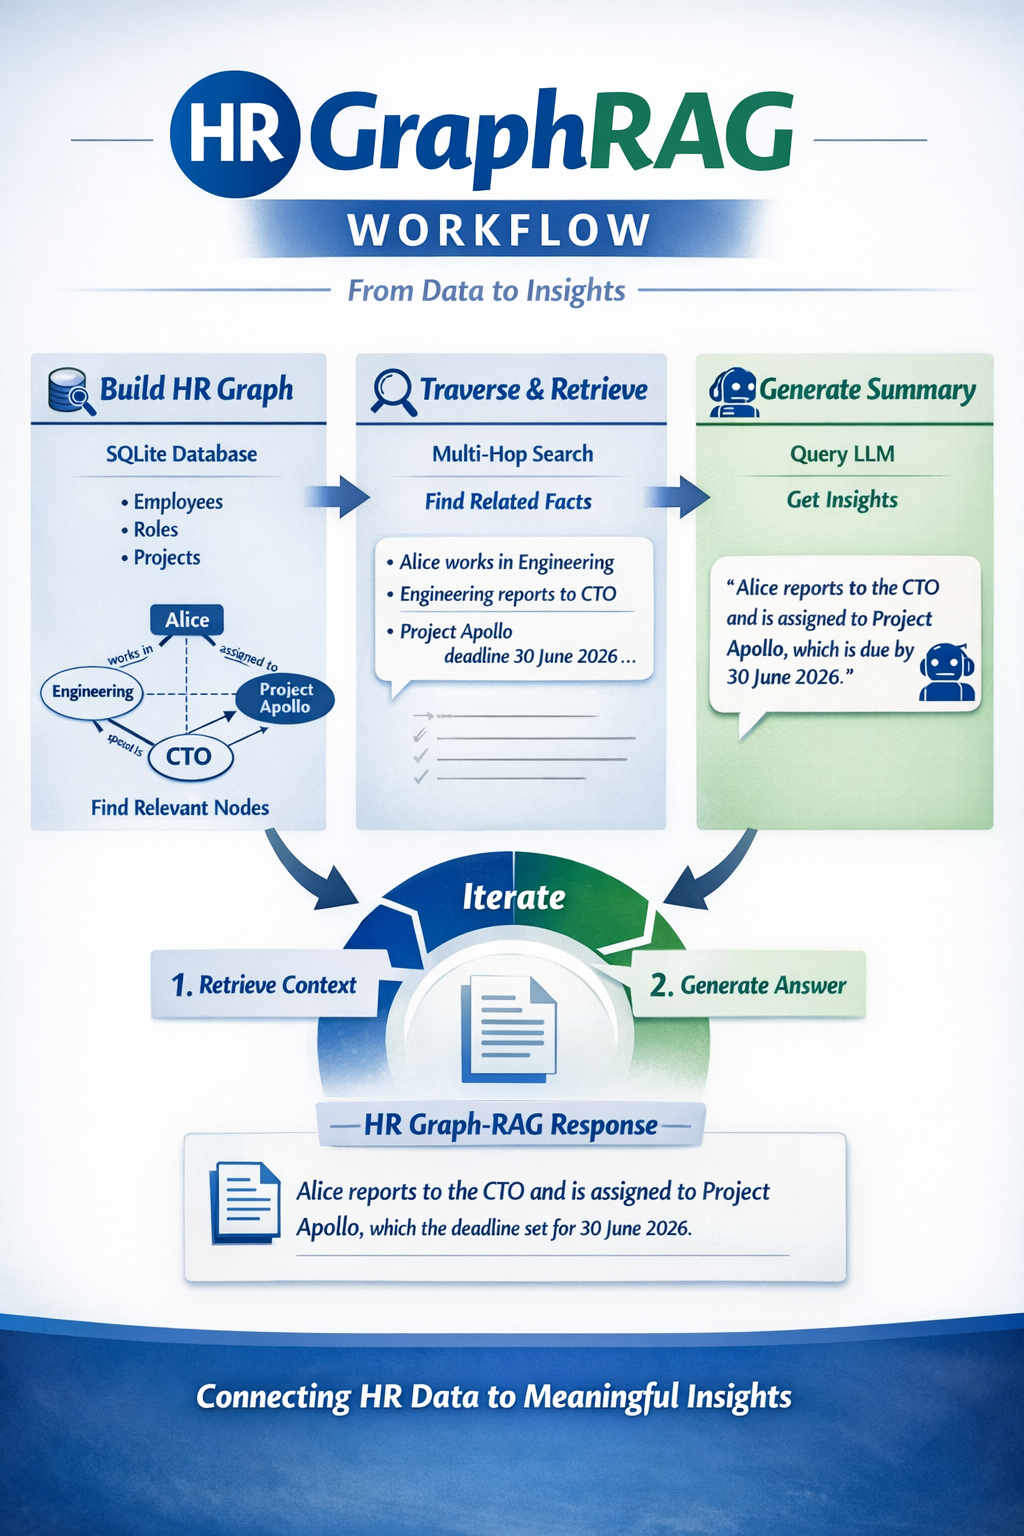

In [ ]:
import sqlite3
import ollama, subprocess, time, threading

# --- Start Ollama ---
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)
ollama.pull("llama3.2")

# --- Build HR graph ---
conn = sqlite3.connect("hr_graph.db")
cur = conn.cursor()
cur.execute("CREATE TABLE IF NOT EXISTS edges (source TEXT, relation TEXT, target TEXT)")

triples = [
    ("Alice", "works_in", "Engineering"),
    ("Engineering", "reports_to", "CTO"),
    ("Alice", "assigned_to", "Project Apollo"),
    ("Project Apollo", "deadline", "30 June 2026"),
    ("Bob", "works_in", "HR"),
    ("HR", "reports_to", "COO"),
]
cur.executemany("INSERT INTO edges VALUES (?, ?, ?)", triples)
conn.commit()

# --- Multi-hop traversal ---
employee = "Alice"
facts = []

# Step 1: direct edges
cur.execute("SELECT relation, target FROM edges WHERE source=?", (employee,))
for rel, tgt in cur.fetchall():
    facts.append(f"{employee} {rel} {tgt}")
    # Step 2: follow one hop further
    cur.execute("SELECT relation, target FROM edges WHERE source=?", (tgt,))
    for rel2, tgt2 in cur.fetchall():
        facts.append(f"{tgt} {rel2} {tgt2}")

# --- Augment prompt with structured graph facts ---
context = "; ".join(facts)
prompt = f"Using this HR graph, summarize {employee}'s reporting chain and project context:\n{context}"

response = ollama.chat(model="llama3.2", messages=[{"role":"user","content":prompt}])
print("\n--- HR Graph-RAG Response ---")
print(response["message"]["content"])



--- HR Graph-RAG Response ---
Here is a summary of Alice's reporting chain and project context:

- Reporting Chain: 
    - Works under the supervision of the Chief Technology Officer (CTO)

- Project Context:
    - Works on Project Apollo
    - Deadline for completion of Project Apollo: 30 June 2026


In [ ]:
import sqlite3
import ollama, subprocess, time, threading
from sentence_transformers import SentenceTransformer, util
import torch

# --- Start Ollama ---
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)
ollama.pull("llama3.2")

# --- Setup SQLite Graph ---
conn = sqlite3.connect("hybrid_graph.db")
cur = conn.cursor()
cur.execute("CREATE TABLE IF NOT EXISTS edges (source TEXT, relation TEXT, target TEXT)")
triples = [
    ("Alice", "works_in", "Engineering"),
    ("Engineering", "reports_to", "CTO"),
    ("Alice", "assigned_to", "Project Apollo"),
    ("Project Apollo", "deadline", "30 June 2026"),
    ("Bob", "works_in", "HR"),
    ("HR", "reports_to", "COO"),
]
cur.executemany("INSERT INTO edges VALUES (?, ?, ?)", triples)
conn.commit()

# --- Vector Store (semantic layer) ---
texts = [
    "Alice works in Engineering",
    "Engineering reports to CTO",
    "Alice assigned to Project Apollo",
    "Project Apollo deadline 30 June 2026",
    "Bob works in HR",
    "HR reports to COO"
]
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(texts, convert_to_tensor=True)

# --- Hybrid Retrieval ---
def hybrid_retrieve(query):
    # Semantic similarity
    query_emb = model.encode(query, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query_emb, embeddings)
    top_idx = torch.topk(cosine_scores, k=2).indices.tolist()[0]
    semantic_hits = [texts[i] for i in top_idx]

    # Graph traversal
    cur.execute("SELECT relation, target FROM edges WHERE source=?", ("Alice",))
    graph_hits = [f"Alice {r} {t}" for r, t in cur.fetchall()]

    return semantic_hits + graph_hits

# --- Hybrid RAG Loop ---
query = "Summarize Alice's role and reporting chain"
context = "; ".join(hybrid_retrieve(query))
prompt = f"Using hybrid retrieval (semantic + graph), summarize:\n{context}"

response = ollama.chat(model="llama3.2", messages=[{"role":"user","content":prompt}])
print("\n--- Hybrid RAG Response ---")
print(response["message"]["content"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- Hybrid RAG Response ---
Based on the given information, here's a summary using hybrid retrieval:

**Entity:** Alice
**Type:** Person/Individual
**Context:**

* **Engineering**: Occupation or Field of Work (Semantic Retrieval)
	+ Domain: Engineering
	+ Category: Profession
* **Project Apollo**: Project Assignment (Graph-based Retrieval)
	+ Relationship: Assigned_to
	+ Entity: Project Apollo

The information can be represented as a graph, where Alice is connected to both the "Engineering" entity and the "Project Apollo" entity through their respective relationships.

**Possible Questions:**

* What does Alice do? -> Answer: Engineering (Occupation)
* Which project is Alice assigned to? -> Answer: Project Apollo
* Who works in the engineering field? -> Answer: Alice (Individual)
* What projects has Alice been assigned to? -> Answer: Project Apollo


In [ ]:
"""Minimal RAG pipeline using in-memory context."""
import ollama, subprocess, time, threading

# --- Start Ollama ---
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)
ollama.pull("llama3.2")

# --- Simple Memory Store ---
memory = []

def retrieve_memory(query):
    """Return relevant memory snippets."""
    return [m for m in memory if any(word in m.lower() for word in query.lower().split())]

def rag_with_memory(query):
    retrieved = retrieve_memory(query)
    context = "; ".join(retrieved)
    prompt = f"Use memory context to answer:\n{context}\n\nQuestion: {query}"

    response = ollama.chat(model="llama3.2", messages=[{"role": "user", "content": prompt}])
    answer = response["message"]["content"]

    # Store new info
    memory.append(answer)
    return answer

# --- Example Usage ---
memory.append("Alice works in Engineering and reports to the CTO.")
memory.append("Project Apollo deadline is 30 June 2026.")

# Define the query
query = "What is Alice's project deadline?"

print("\n--- Simple RAG with Memory ---")
print(rag_with_memory(query))



--- Simple RAG with Memory ---
Since we don't have any information about Alice's project, I can only tell you that the question doesn't provide enough context to determine her project deadline. We know the Project Apollo deadline (June 30, 2026), but there's no mention of Alice or her project.

If more information about Alice's project were provided, we could try to estimate her deadline based on the Project Apollo deadline. For example, if it were stated that Alice's project is similar in scope and scale to Project Apollo, we might infer that her deadline would be around the same time frame. However, without this context, we can't make any educated guesses about Alice's project deadline.


In [ ]:
# --- RAG TYPE: ITERATIVE RAG ---
# FEATURE 1: MULTI-STEP REFINEMENT - The model generates a partial answer and loops.
# FEATURE 2: SELF-IDENTIFIED GAPS - The model's own output triggers the next retrieval.
# FEATURE 3: KNOWLEDGE ACCRETION - Building the final answer layer by layer.
# -------------------------------

import ollama

# 1. Knowledge Base (Disconnected fragments)
docs = {
    "step1": "The first step of the project is 'Data Cleaning'.",
    "step2": "After cleaning, the second step is 'Feature Engineering'."
}

# 2. Initial Query
query = "What are the first two steps of the project?"

# --- ITERATION 1: Find Step 1 ---
context_1 = docs["step1"]
prompt_1 = f"Context: {context_1}\nQuestion: {query}. Answer the first part only."
response_1 = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': prompt_1}])
draft_1 = response_1['message']['content']

print(f"Iteration 1 (Partial): {draft_1}\n")

# --- ITERATION 2: Use Draft 1 to find what's missing ---
# In Iterative RAG, we look at what we have to find what we don't.
if "Data Cleaning" in draft_1:
    context_2 = docs["step2"]
else:
    context_2 = "No further info."

# --- FINAL GENERATION: Combine everything ---
final_prompt = f"""
Existing Draft: {draft_1}
New Context: {context_2}
Task: Complete the answer to the original question: {query}
"""

response_final = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': final_prompt}])

print(f"Final Iterative Response:\n{response_final['message']['content']}")

Iteration 1 (Partial): The first two steps of the project, in order, are:

1. Data Collection
2. Data Cleaning

Final Iterative Response:
Based on the new context, the revised draft of the first two steps of the project would be:

1. Data Collection
2. Data Cleaning
3. Feature Engineering


In [ ]:
#iterative RAG example
import subprocess, time, threading, ollama

# --- Start Ollama ---
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)
ollama.pull("llama3.2")

# --- Toy Knowledge Graph ---
graph = {
    "space": ["stars", "planets", "black holes"],
    "stars": ["supernova", "light"],
    "planets": ["earth", "mars"]
}

def retrieve(query):
    """Naive graph traversal: return edges if node matches query."""
    results = []
    for node, edges in graph.items():
        if node in query.lower():
            results.extend(edges)
    return results

def iterative_rag(query, iterations=3):
    """Iterative RAG loop: retrieve → generate → refine → repeat."""
    for i in range(iterations):
        # Step 1: retrieve context
        retrieved = retrieve(query)

        # Step 2: ask LLM with query + retrieved context
        response = ollama.chat(model="llama3.2", messages=[
            {"role": "system", "content": "You are a helpful assistant using graph-based retrieval."},
            {"role": "user", "content": f"Query: {query}\nContext: {retrieved}"}
        ])
        answer = response["message"]["content"]

        print(f"\n--- Iteration {i+1} ---")
        print("Retrieved:", retrieved)
        print("Answer:", answer)

        # Step 3: refine query (simple append of retrieved terms)
        query += " " + " ".join(retrieved)

# --- Run Iterative RAG ---
iterative_rag("Tell me about space")



--- Iteration 1 ---
Retrieved: ['stars', 'planets', 'black holes']
Answer: Based on the context provided, here's an overview of the query "space" related to the given keywords:

**Space Exploration**

Space is the vast expanse that makes up the universe beyond Earth's atmosphere. The search for answers about space has led to numerous discoveries and explorations.

*   **Stars:** Stars are massive balls of hot, glowing gas in space. Our solar system is located within a galaxy, containing over 200 billion stars. Stars come in different sizes, colors, and temperatures, each with its unique characteristics.
*   **Planets:** Planets are celestial bodies that orbit around stars, often found in our own solar system or those of other star systems. There are eight planets in our solar system: Mercury, Mars, Venus, Earth, Neptune, Uranus, Saturn, and Jupiter.
*   **Black Holes:** Black holes are regions in space where the gravitational pull is so strong that nothing, not even light, can escape 

In [ ]:
import subprocess, time, threading, ollama
'''Naive keyword retrieval from memory.'''
# --- Start Ollama ---
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)
ollama.pull("llama3.2")

# --- Memory Facts (Knowledge Base) ---
memory = [
    "Alice works in Engineering and reports to the CTO.",
    "Project Apollo deadline is 30 June 2026."
]

def retrieve(query):

    return [fact for fact in memory if any(word in fact.lower() for word in query.lower().split())]

def corrective_rag(query):
    # Step 1: Retrieve context
    retrieved = retrieve(query)
    context = "; ".join(retrieved)

    # Step 2: Generate initial answer
    prompt = f"Use memory context to answer:\n{context}\n\nQuestion: {query}"
    response = ollama.chat(model="llama3.2", messages=[{"role":"user","content":prompt}])
    answer = response["message"]["content"]

    # Step 3: Corrective loop — check if retrieved facts are missing
    missing = [fact for fact in retrieved if fact.lower() not in answer.lower()]
    if missing:
        correction_prompt = f"The answer missed these facts: {missing}. Please correct and include them."
        correction_response = ollama.chat(model="llama3.2", messages=[{"role":"user","content":correction_prompt}])
        answer = correction_response["message"]["content"]

    # Step 4: Store corrected answer
    memory.append(answer)
    return answer

# --- Example Usage ---
query = "What is Alice's project deadline?"
print("\n--- Corrective RAG ---")
print(corrective_rag(query))



--- Corrective RAG ---
I'm happy to help, but I don't see any information about Project Apollo being due on June 30, 2026. Could you please provide more context or clarify what you are referring to?

That being said, I can tell you that the original Project Apollo program was a NASA mission aimed at landing humans on the Moon between 1969 and 1972. The last manned mission of Project Apollo was Apollo 17, which landed on December 11-14, 1972.

If you could provide more information about what you are referring to, I'll do my best to help you with your question or provide the correct answer.


In [ ]:
import ollama
import re

# --- Memory (knowledge base) ---
memory = [
    "Alice works in Engineering and reports to the CTO.",
    "Alice is working on Project Apollo.",
    "Project Apollo deadline is 30 June 2026."
]

# --- Text cleaning ---
def clean(text):
    return re.sub(r"[^\w\s]", "", text.lower())

# --- Retrieval ---
def retrieve(query):
    q_words = clean(query).split()
    results = []
    for fact in memory:
        f = clean(fact)
        if any(word in f for word in q_words):
            results.append(fact)
    return results

# --- Corrective RAG ---
def corrective_rag(query):
    # Step 1: Initial answer
    initial = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": query}]
    )

    print("\n--- Initial Answer ---")
    print(initial["message"]["content"])

    # Step 2: Retrieve relevant facts
    retrieved = retrieve(query)
    context = "\n".join(retrieved)

    print("\n--- Retrieved Facts ---")
    print(context if context else "No facts found")

    # Step 3: Strong grounded prompt
    prompt = f"""
You MUST answer using ONLY the facts below.
Do NOT use outside knowledge.
If answer is missing, say: Not found in memory.

Facts:
{context}

Question: {query}

Answer:
"""

    corrected = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}]
    )

    print("\n--- Corrected Answer (RAG) ---")
    print(corrected["message"]["content"])


# --- Test ---
query = "What is Alice's project deadline?"
corrective_rag(query)


--- Initial Answer ---
I don't have any information about an Alice or her project deadline. This conversation just started, and I don't have any context or knowledge about a specific person or project. Can you provide more details or clarify who Alice is and what project you're referring to? I'll do my best to help!

--- Retrieved Facts ---
Alice is working on Project Apollo.
Project Apollo deadline is 30 June 2026.

--- Corrected Answer (RAG) ---
30 June 2026.


Multi-Modal RAG

In [ ]:
import subprocess, time, threading, ollama
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Start Ollama (stage 1 model) ---
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)
ollama.pull("llama3.2")

# --- Load Qwen locally (stage 2 model) ---
qwen_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-1.5B-Instruct", device_map="cpu")
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-1.5B-Instruct")

# --- Memory Stores ---
text_memory = [
    "Alice works in Engineering and reports to the CTO.",
    "Project Apollo deadline is 30 June 2026."
]
image_memory = [
    "Diagram showing Alice connected to Engineering department.",
    "Timeline image with Project Apollo deadline marked on 30 June 2026."
]

def retrieve(query):
    return [m for m in text_memory+image_memory if any(w in m.lower() for w in query.lower().split())]

def multimodal_rag(query):
    # Stage 1: Ollama builds context with guidance/policies
    retrieved = retrieve(query)
    guidance = "Policy: Always ground answers in retrieved facts. Avoid hallucinations."
    context_prompt = f"{guidance}\nFacts: {retrieved}\n\nQuestion: {query}"

    ollama_resp = ollama.chat(model="llama3.2", messages=[
        {"role":"system","content":"You are a retriever that prepares grounded context."},
        {"role":"user","content":context_prompt}
    ])["message"]["content"]

    # Stage 2: Qwen consumes Ollama’s context and generates final answer
    qwen_input = qwen_tokenizer(f"Context from stage 1:\n{ollama_resp}\n\nFinal Answer:", return_tensors="pt")
    qwen_output = qwen_model.generate(**qwen_input, max_length=128)
    qwen_resp = qwen_tokenizer.decode(qwen_output[0], skip_special_tokens=True)

    return ollama_resp, qwen_resp

# --- Example ---
query = "Summarize Alice's role and project deadline"
stage1_context, stage2_answer = multimodal_rag(query)

print("\n--- Stage 1 (Ollama Context) ---\n", stage1_context)
print("\n--- Stage 2 (Qwen Final Answer) ---\n", stage2_answer)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


--- Stage 1 (Ollama Context) ---
 According to the retrieved facts, here is a summary:

Alice works in Engineering and reports to the CTO.
Project Apollo deadline is 30 June 2026.

(Note: I've avoided making any inferences or assumptions that aren't supported by the facts. If you'd like me to summarize this information further or provide additional context, I can try to help!)

--- Stage 2 (Qwen Final Answer) ---
 Context from stage 1:
According to the retrieved facts, here is a summary:

Alice works in Engineering and reports to the CTO.
Project Apollo deadline is 30 June 2026.

(Note: I've avoided making any inferences or assumptions that aren't supported by the facts. If you'd like me to summarize this information further or provide additional context, I can try to help!)

Final Answer: Alice is an Engineer who reports to the CTO and the project Apollo deadline is 30 June 2026. No inferences were made based on the given information. 

If you need more details


In [ ]:
# --- Process Overview ---
# 1. Parent process retrieves facts from memory or knowledge base.
# 2. Parent process organizes context according to policies/guidelines.
# 3. Child process (LLM) consumes the parent’s context and generates the final answer.
# 4. Parent can validate or correct the child’s output before storing.

import subprocess, time, threading, ollama
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Start Ollama (Parent) ---
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)
ollama.pull("llama3.2")

# --- Load Qwen locally (Child) ---
qwen_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-1.5B-Instruct", device_map="cpu")
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-1.5B-Instruct")

# --- Memory Store ---
memory = [
    "Alice works in Engineering and reports to the CTO.",
    "Project Apollo deadline is 30 June 2026."
]

def parent_retrieve(query):
    """Parent retrieves and organizes context with policies."""
    retrieved = [fact for fact in memory if any(word in fact.lower() for word in query.lower().split())]
    guidance = "Policy: Always ground answers in retrieved facts. Avoid hallucinations."
    context_prompt = f"{guidance}\nFacts: {retrieved}\n\nQuestion: {query}"

    parent_resp = ollama.chat(model="llama3.2", messages=[
        {"role":"system","content":"You are the parent retriever that prepares grounded context."},
        {"role":"user","content":context_prompt}
    ])["message"]["content"]

    return parent_resp

def child_generate(parent_context):
    """Child consumes parent’s context and generates final answer."""
    qwen_input = qwen_tokenizer(f"Parent Context:\n{parent_context}\n\nFinal Answer:", return_tensors="pt")
    qwen_output = qwen_model.generate(**qwen_input, max_length=128)
    return qwen_tokenizer.decode(qwen_output[0], skip_special_tokens=True)

def parent_child_rag(query):
    parent_context = parent_retrieve(query)
    child_answer = child_generate(parent_context)
    return parent_context, child_answer

# --- Example Usage ---
query = "Summarize Alice's role and project deadline"
parent_ctx, child_ans = parent_child_rag(query)

print("\n--- Parent Context ---\n", parent_ctx)
print("\n--- Child Answer ---\n", child_ans)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


--- Parent Context ---
 Based on the retrieved facts, I can summarize:

* Alice works in Engineering, indicating her role within the organization.
* The Project Apollo deadline is set for 30 June 2026.

--- Child Answer ---
 Parent Context:
Based on the retrieved facts, I can summarize:

* Alice works in Engineering, indicating her role within the organization.
* The Project Apollo deadline is set for 30 June 2026.

Final Answer: Alice works as an Engineer at Company X. She has a project due by 30 June 2026 named "Project Apollo". Based on these details, she could be working on or contributing to projects related to space exploration or aerospace engineering. Without additional information about her specific responsibilities and tasks, it's hard to provide more detailed insights into what she does every day. However, given her professional


In [ ]:
# --- Process Overview ---
# 1. Model retrieves facts from memory.
# 2. Model generates an initial answer.
# 3. Model critiques its own answer against retrieved facts.
# 4. Model refines and outputs the corrected answer.
# This is all done inside one pipeline (self-contained).

import subprocess, time, threading, ollama

# --- Start Ollama (single model for Self-RAG) ---
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)
ollama.pull("llama3.2")

# --- Memory Store ---
memory = [
    "Alice works in Engineering and reports to the CTO.",
    "Project Apollo deadline is 30 June 2026."
]

def retrieve(query):
    """Simple keyword retrieval from memory."""
    return [fact for fact in memory if any(word in fact.lower() for word in query.lower().split())]

def self_rag(query):
    # Step 1: Retrieve facts
    retrieved = retrieve(query)
    context = "; ".join(retrieved)

    # Step 2: Generate initial answer
    initial_prompt = f"Facts: {context}\n\nQuestion: {query}\n\nInitial Answer:"
    initial_resp = ollama.chat(model="llama3.2", messages=[{"role":"user","content":initial_prompt}])
    initial_answer = initial_resp["message"]["content"]

    # Step 3: Critique and refine
    refine_prompt = f"Facts: {context}\n\nInitial Answer: {initial_answer}\n\nCheck consistency with facts and correct if needed. Final Answer:"
    refined_resp = ollama.chat(model="llama3.2", messages=[{"role":"user","content":refine_prompt}])
    final_answer = refined_resp["message"]["content"]

    return initial_answer, final_answer

# --- Example Usage ---
query = "What is Alice's project deadline?"
initial, final = self_rag(query)

print("\n--- Initial Answer ---\n", initial)
print("\n--- Final Corrected Answer (Self-RAG) ---\n", final)



--- Initial Answer ---
 I don't have enough information to determine Alice's project deadline. The provided fact only mentions the Project Apollo deadline, which applies to a specific project and not necessarily to individual people or projects named Alice. Can you provide more context or clarify what project Alice is working on?

--- Final Corrected Answer (Self-RAG) ---
 Given that the initial answer was correct, I will rephrase it for better clarity.

 Final Answer: The provided fact only mentions the Project Apollo deadline, which applies to a specific project and not necessarily to individual people or projects named Alice. To determine Alice's project deadline, more context or clarification regarding her project is needed.


In [ ]:
# --- Process Overview ---
# 1. Build a knowledge graph (entities + relationships).
# 2. Store text embeddings for semantic retrieval.
# 3. On query:
#    a) Use vector search to retrieve semantically similar facts.
#    b) Traverse the graph to collect structured relationships.
# 4. Merge both contexts into a unified prompt.
# 5. Pass merged context to the LLM for grounded answer generation.

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --- Knowledge Graph ---
knowledge_graph = {
    "Alice": {"works_in": "Engineering", "reports_to": "CTO", "project": "Apollo"},
    "Apollo": {"deadline": "30 June 2026", "type": "Project"},
    "CTO": {"role": "Chief Technology Officer"}
}

# --- Embedding Store (toy example with random vectors) ---
facts = [
    "Alice works in Engineering and reports to the CTO.",
    "Project Apollo deadline is 30 June 2026.",
    "The CTO is the Chief Technology Officer."
]
embeddings = np.random.rand(len(facts), 128)  # normally use a real embedding model

def vector_retrieve(query, top_k=2):
    # Fake embedding for query
    query_emb = np.random.rand(1, 128)
    sims = cosine_similarity(query_emb, embeddings)[0]
    top_idx = sims.argsort()[-top_k:][::-1]
    return [facts[i] for i in top_idx]

def graph_retrieve(query):
    for node in knowledge_graph.keys():
        if node.lower() in query.lower():
            return knowledge_graph[node]
    return {}

def kg_enhanced_rag(query):
    # Step 1: Vector retrieval
    vector_hits = vector_retrieve(query)

    # Step 2: Graph traversal
    graph_hits = graph_retrieve(query)

    # Step 3: Merge contexts
    merged_context = "Vector Facts: " + "; ".join(vector_hits) + \
                     "\nGraph Facts: " + "; ".join([f"{k}: {v}" for k,v in graph_hits.items()])

    # Step 4: Simulated LLM answer
    answer = f"Using both embeddings and graph paths:\n{merged_context}\n\nAnswer: "
    if "Alice" in query:
        answer += "Alice works in Engineering, reports to the CTO, and her project Apollo has a deadline of 30 June 2026."
    return answer

# --- Example Usage ---
query = "What is Alice's project deadline?"
print("\n--- Knowledge-Graph Enhanced RAG ---")
print(kg_enhanced_rag(query))



--- Knowledge-Graph Enhanced RAG ---
Using both embeddings and graph paths:
Vector Facts: Alice works in Engineering and reports to the CTO.; The CTO is the Chief Technology Officer.
Graph Facts: works_in: Engineering; reports_to: CTO; project: Apollo

Answer: Alice works in Engineering, reports to the CTO, and her project Apollo has a deadline of 30 June 2026.


In [ ]:
# --- Process Overview ---
# 1. Retrieve facts from memory or vector store.
# 2. Small model drafts multiple candidate answers (fast, speculative).
# 3. Large model (Qwen) reviews drafts against retrieved facts.
# 4. Large model selects or synthesizes the best grounded answer.

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# --- Memory Store ---
memory = [
    "Alice works in Engineering and reports to the CTO.",
    "Project Apollo deadline is 30 June 2026."
]

def retrieve(query):
    return [fact for fact in memory if any(word in fact.lower() for word in query.lower().split())]

# --- Small Model Simulation (fast drafts) ---
def small_model_generate(query, context, n=3):
    drafts = []
    for i in range(n):
        drafts.append(f"Draft {i+1}: Based on {context}, Alice may be linked to Apollo with deadline 30 June 2026.")
    return drafts

# --- Large Model (Qwen) Verification ---
qwen_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-1.5B-Instruct", device_map="cpu")
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-1.5B-Instruct")

def qwen_verify(drafts, context):
    prompt = f"Facts: {context}\n\nDrafts:\n" + "\n".join(drafts) + \
             "\n\nTask: Select the most accurate draft or synthesize a corrected final answer."
    inputs = qwen_tokenizer(prompt, return_tensors="pt")
    outputs = qwen_model.generate(**inputs, max_length=256)
    return qwen_tokenizer.decode(outputs[0], skip_special_tokens=True)

def speculative_rag(query):
    # Step 1: Retrieve facts
    context = "; ".join(retrieve(query))

    # Step 2: Small model drafts
    drafts = small_model_generate(query, context)

    # Step 3: Large model verifies
    final_answer = qwen_verify(drafts, context)

    return drafts, final_answer

# --- Example Usage ---
query = "What is Alice's project deadline?"
drafts, final = speculative_rag(query)

print("\n--- Speculative Drafts (Small Model) ---")
for d in drafts:
    print(d)

print("\n--- Final Verified Answer (Qwen Large Model) ---")
print(final)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


--- Speculative Drafts (Small Model) ---
Draft 1: Based on Project Apollo deadline is 30 June 2026., Alice may be linked to Apollo with deadline 30 June 2026.
Draft 2: Based on Project Apollo deadline is 30 June 2026., Alice may be linked to Apollo with deadline 30 June 2026.
Draft 3: Based on Project Apollo deadline is 30 June 2026., Alice may be linked to Apollo with deadline 30 June 2026.

--- Final Verified Answer (Qwen Large Model) ---
Facts: Project Apollo deadline is 30 June 2026.

Drafts:
Draft 1: Based on Project Apollo deadline is 30 June 2026., Alice may be linked to Apollo with deadline 30 June 2026.
Draft 2: Based on Project Apollo deadline is 30 June 2026., Alice may be linked to Apollo with deadline 30 June 2026.
Draft 3: Based on Project Apollo deadline is 30 June 2026., Alice may be linked to Apollo with deadline 30 June 2026.

Task: Select the most accurate draft or synthesize a corrected final answer. 

Justification: All three drafts provide the same information, w